In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.io import wavfile


# Звук телефонного автомата

In [2]:
payphone = 'payphone-sound.wav'
samplerate, data = wavfile.read(payphone)

In [3]:
print('Sampling Rate:', samplerate)
print('Audio Shape:', np.shape(data))

Sampling Rate: 22050
Audio Shape: (38352,)


In [4]:
duration = len(data) / samplerate
time = np.arange(0, duration, 1 / samplerate)  #time vector
duration

1.7393197278911565

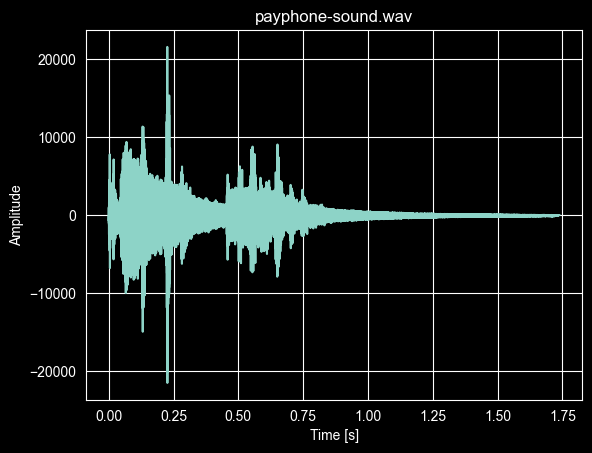

In [5]:

plt.plot(time, data)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('payphone-sound.wav')
plt.show()

## Рассчет спектра

Вычислим только правую часть спектра, т.к он семетричен

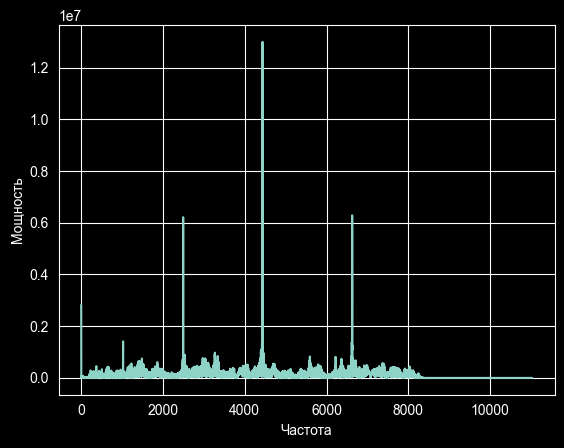

In [6]:
from scipy.fft import rfft, rfftfreq

# число точек в normalized_tone
N = int(samplerate * duration)

yf = rfft(data)
xf = rfftfreq(N, 1 / samplerate)

plt.plot(xf, np.abs(yf))
plt.xlabel('Частота')
plt.ylabel('Мощность')
plt.show()

## Рассчет спектограммы

In [7]:
adata = data
s = samplerate
fr, tm, spgram = signal.spectrogram(adata, s)
lspg = np.log(spgram + 1e-10)

## Мел-спектральные коэф. MFCC

In [8]:
samples, sample_rate = librosa.load("payphone-sound.wav")

y = samples
sr = sample_rate
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)

## Рассчет GFCC

In [9]:
import scipy.io.wavfile
from spafe.features.gfcc import gfcc

#read wave file
fs, sig = scipy.io.wavfile.read('payphone-sound.wav')

# compute gfccs

gfccs = gfcc(sig=sig, fs=fs, num_ceps=13)

## График спектограммы

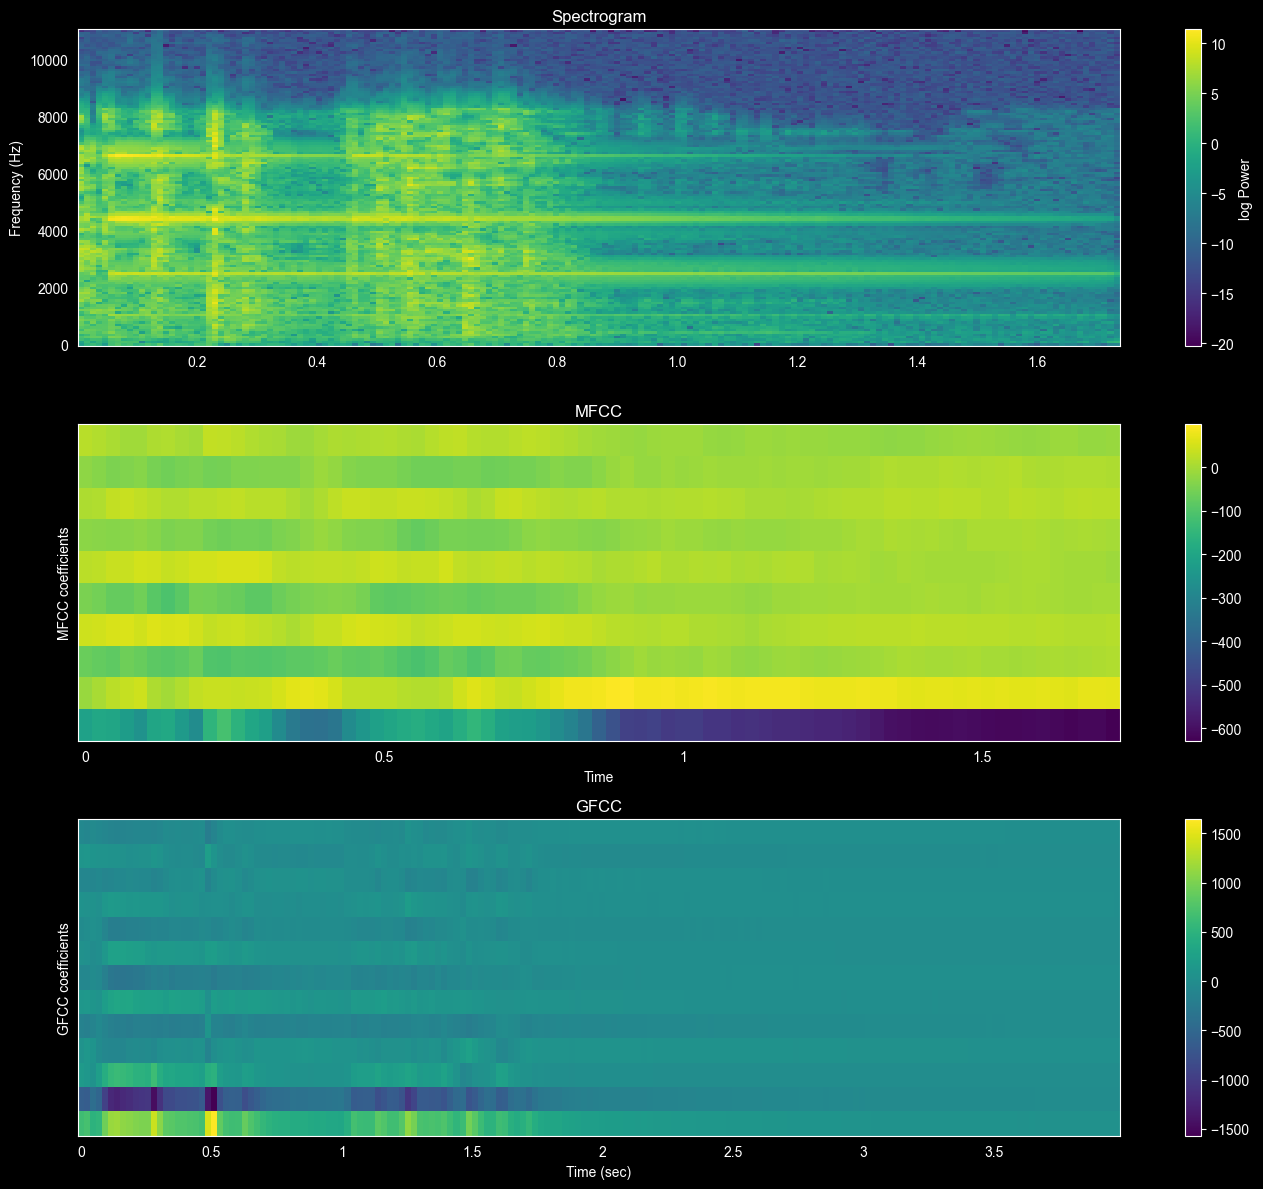

In [10]:
fig, axes = plt.subplots(nrows=3, figsize=(14, 12))

# Спектрограмма
fr, tm, spgram = signal.spectrogram(adata, s)
lspg = np.log(spgram + 1e-10)
pcm = axes[0].pcolormesh(tm, fr, lspg, shading='auto', cmap='viridis')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Spectrogram')
plt.colorbar(pcm, ax=axes[0], label='log Power')

# MFCC
img1 = librosa.display.specshow(mfccs, x_axis='time', ax=axes[1], cmap='viridis')
axes[1].set(title='MFCC')
axes[1].set_ylabel('MFCC coefficients')
plt.colorbar(img1, ax=axes[1])

#  GFCC
img2 = librosa.display.specshow(gfccs.T, x_axis='time', ax=axes[2], cmap='viridis')
axes[2].set(title='GFCC')
axes[2].set_ylabel('GFCC coefficients')
axes[2].set_xlabel('Time (sec)')
plt.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.show()

# Звук портала

In [11]:
portal_star = 'portal-star-or-space-gate-2.wav'
samplerate_ps, data_ps = wavfile.read(portal_star)

In [12]:
print('Sampling Rate:', samplerate_ps)
print('Audio Shape:', np.shape(data_ps))

Sampling Rate: 44100
Audio Shape: (2028143, 2)


In [13]:
duration_ps = len(data_ps) / samplerate_ps
time_ps = np.arange(0, duration_ps, 1 / samplerate_ps)  #time vector
duration_ps

45.98963718820862

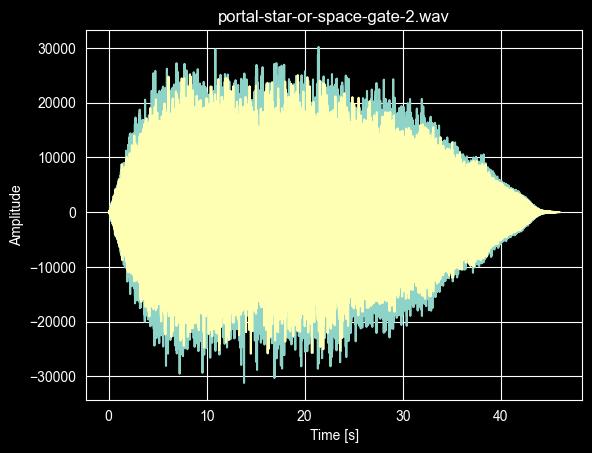

In [14]:
plt.plot(time_ps, data_ps)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('portal-star-or-space-gate-2.wav')
plt.show()

## Рассчет спектограммы

In [15]:
adata_ps = data_ps[:, 1]
s_ps = samplerate_ps
fr_ps, tm_ps, spgram_ps = signal.spectrogram(adata_ps, s_ps)
lspg_ps = np.log(spgram_ps + 1e-10)

## Рассчет MFCC

In [16]:
import librosa

s, sr = librosa.load("portal-star-or-space-gate-2.wav")

mfccs = librosa.feature.mfcc(y=s, sr=sr, n_mfcc=10)

## Рассчет GFCC

In [17]:
from spafe.features.gfcc import gfcc

#read wave file
fs, sig = wavfile.read('portal-star-or-space-gate-2.wav')

# compute gfccs

gfccs = gfcc(sig=sig, fs=fs, num_ceps=13)

## График спектограммы

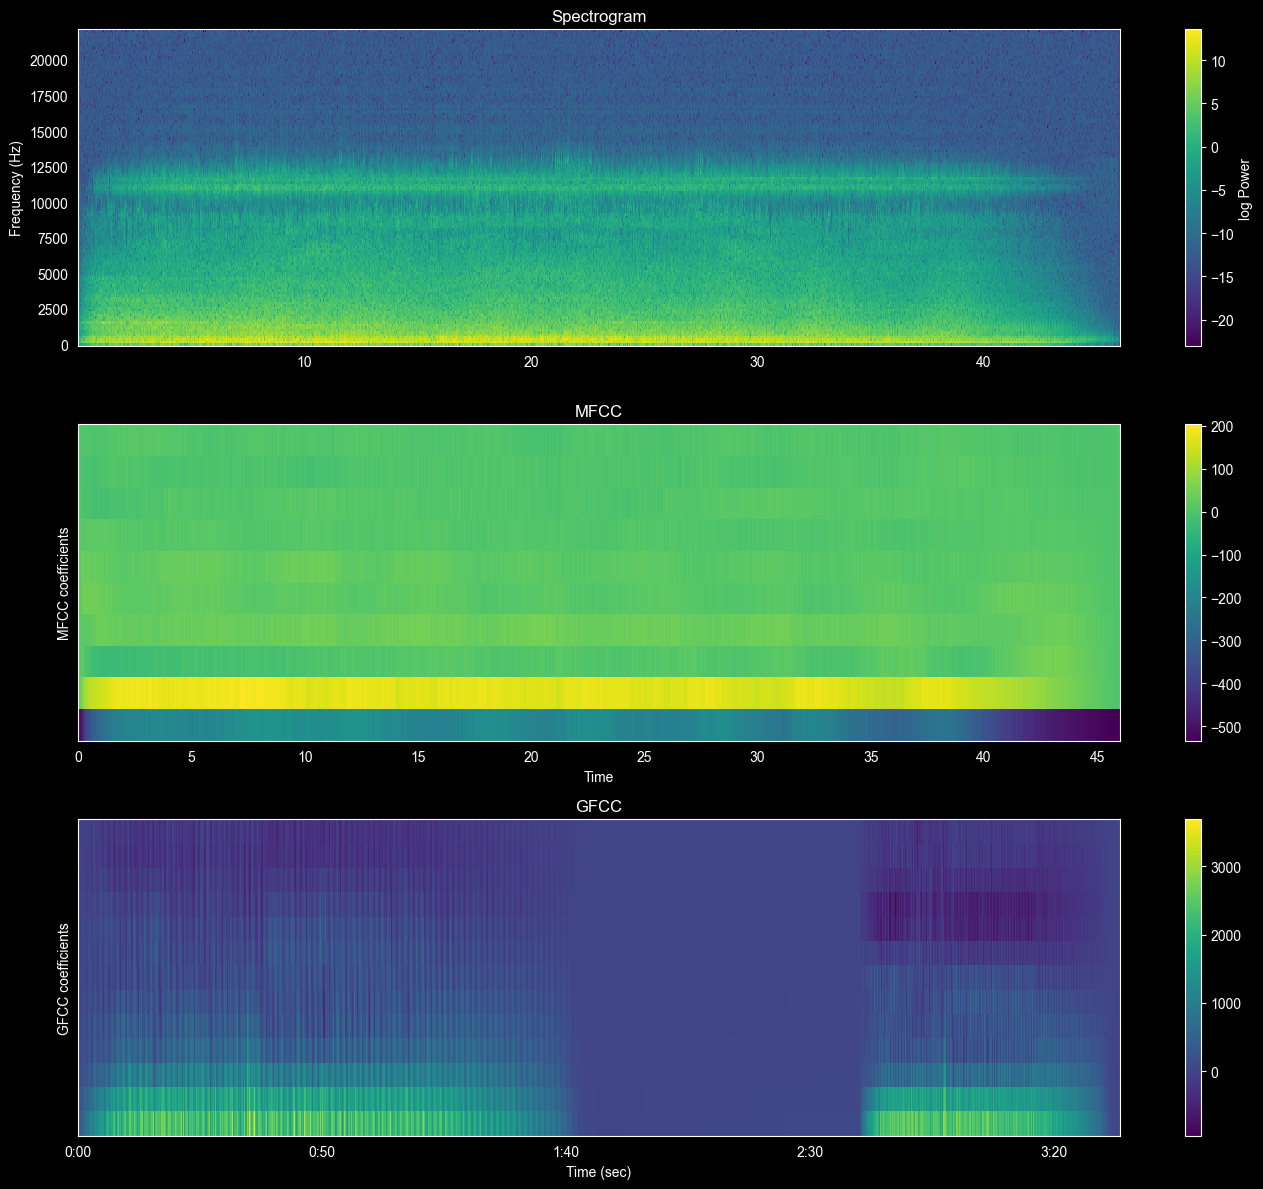

In [18]:
fig, axes = plt.subplots(nrows=3, figsize=(14, 12))

# Спектрограмма
pcm = axes[0].pcolormesh(tm_ps, fr_ps, lspg_ps, shading='auto', cmap='viridis')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Spectrogram')
plt.colorbar(pcm, ax=axes[0], label='log Power')

# MFCC
img1 = librosa.display.specshow(mfccs, x_axis='time', ax=axes[1], cmap='viridis')
axes[1].set(title='MFCC')
axes[1].set_ylabel('MFCC coefficients')
plt.colorbar(img1, ax=axes[1])

#  GFCC
img2 = librosa.display.specshow(gfccs.T, x_axis='time', ax=axes[2], cmap='viridis')
axes[2].set(title='GFCC')
axes[2].set_ylabel('GFCC coefficients')
axes[2].set_xlabel('Time (sec)')
plt.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.show()

# Анализ спектограмм

Сходства:
*     В обеих есть заметная энергия в высокочастотной области (зелёный/жёлтый цвет).
*     Обе представляют стационарный / относительно стабильный сигнал без резких пауз.

Различия:
*     Длительность 1.7с и 46с
* Структура: первая — яркие горизонтальные гармоники/тоны + заметная временная динамика (всплеск → затухание), вторая — почти равномерный шумовой фон без выраженных тонов.
* Энергетическая насыщенность: первая гораздо ярче и контрастнее, вторая — слабая, размазанная, «тише» по ощущениям.